# Swarm Data Fusion toolbox demo notebook

**SwarmDF is a Python tool for end-to-end automated data fusion, electrodynamics reconstruction, and validation along a Swarm satellite trajectory. It enables interpretation of Swarm observations within their broader electrodynamic context, supporting well-constrained studies of high-latitude ionospheric electrodynamics.**

This notebook documents the SwarmDF Python module and guides the reader step by step through a typical workflow.

Users may run `SwarmDF_GUI.py` to access a user-friendly graphical user interface, which provides guidance through the workflow and allows user to run their own experiment. 

## Imports

In [1]:
from datetime import datetime
from IPython.display import Image as IPImage, display
from pathlib import Path

from swarmdf import *

Path to output directory

In [2]:
package_root = Path.cwd().parents[2]
output_dir = package_root / "outputs"

## Input

### Satellite and time 

**We start by selecting a Swarm satellite and defining the time interval and time step for our study.**

The time interval defines the portion of the satellite trajectory used for the analysis. If it spans multiple Swarm passes, multiple trajectory segments are included.

SwarmDF will perform the analysis at each time step along the selected trajectory.

In [3]:
sat_id = 'B'
start = datetime(2014, 12, 15, 1, 10, 0)
end   = datetime(2014, 12, 15, 1, 11, 0) #20
time_step = 30 # [s] (minimum 10 s)

This is the only required input for running SwarmDF. All other parameters will use default values if not specified.

### Grids along the Swarm trajectory

**Next, we define the extent and spatial resolution of the 2D analysis grids.**

SwarmDF will build cubed-sphere grids along the Swarm trajectory. These grids define the analysis region around the selected satellite at each time step. They are centered on the satellite track and aligned with its velocity vector.

The start and end times above actually specify where the first and last analysis grids are centered along the trajectory. Additional grid centers are placed between them according to the chosen time step. In other words, the time interval specified above defines the range of grid centers, not the exact analysis bounds. 

The real analysis interval for each grid is determined dynamically during processing and depends on the grid size. Each grid uses all available data within its spatial extent.

In [4]:
# The grid parameters must be provided as a dictionary
grid_params = {"L": 2000, # along-track dimension [km] 
               "W": 1500, # cross-track dimension [km]
               "Lres": 200, # along-track resolution [km]
               "Wres": 200, # cross-track resolution [km]
               "wshift": 0} # cross-track shift of grid center [km] 

Note on `wshift`: 
The Swarm trajectory is intended to pass through the center of each grid. However, depending on the grid dimensions and geometry, it may be slightly offset.
`wshift` allows us to shift the grid center in the cross-track direction to better align it with the Swarm track. A positive (negative) value shifts the grid center to the left (right).

### Datasets

**Now, we choose datasets** from: 
- Swarm (magnetic field and cross-track ion drift)
- SuperDARN (line-of-sight velocities)
- SuperMAG (ground magnetometer perturbations)
- Iridium/AMPERE (field-aligned currents)
- DMSP/SSIES (ion drift)

The selected datasets will be used to reconstruct the ionospheric electrodynamics across the sequence of grids along the Swarm trajectory.

Data documentation is available at (link) ⚠️ TODO

In [5]:
# Supported dataset names: 
# 'superdarn', 'supermag', 'iridium_ampere', 'swarm_mag', 'swarm_efield', 'dmsp_ssies17', 'dmsp_ssies18' 
# #TODO add Swarm ion flow
datasets2download = ['swarm_mag', 'superdarn', 'supermag', 'iridium_ampere', "dmsp_ssies17", "dmsp_ssies18"]

**From this point on, everything is handled automatically by SwarmDF, up to the validation stage.** 

The Lompe reconstruction (see below) will use default conductance and regularization parameters unless specified otherwise.

## Data fusion 

**Data loading**

SwarmDF automatically retrieves and loads all available datasets for the specified time interval.

In [6]:
datahandler = DataManager(start, end, datasets2download, demo = False) # Turn demo to True if you want to skip data collection and use sample datasets for example event 2014-12-15
datasets = datahandler.datasets # dictionnary of DataFrames

Downloading/retrieving data...
SuperDARN file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_superdarn_grdmap.h5.
DMSP/SSIES F18 file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_ssies_f18.h5
SuperMAG file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_supermag.h5.
Swarm MAG file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_swarm_mag.h5.
DMSP/SSIES F17 file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_ssies_f17.h5
Iridium/AMPERE file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_iridium.h5.
Loading data...
swarm_mag dataset loaded.
superdarn dataset loaded.
supermag dataset loaded.
iridium_ampere dataset loaded.
dmsp_ssies17 dataset loaded.
dmsp_ssies18 dataset loaded.


**Lompe input preparation**

Here, SwarmDF:
- Extracts the relevant portion of the Swarm trajectory
- Constructs analysis grids along the trajectory
- Builds Lompe data objects for each grid (data ready for inversion)


In [7]:
lompe_input = LompeInput(sat_id, start, end, datasets)
grids, analysis_times = lompe_input.build_grids_around_swarm(time_step, grid_params)
data_objects_per_grid = lompe_input.prepare_lompe_input(grids, analysis_times) 

Preparing Lompe input...
Distance from center time: t0 → ct_swarm = 135.0 s, ct_swarm → t1 = 115.0 s
Distance from center time: t0 → ct_swarm = 135.0 s, ct_swarm → t1 = 115.0 s


**Next, we visualize the Lompe input to inspect the experiment configuration.**

This step visualizes the input data used for the Lompe analysis along the selected Swarm trajectory. It allows us to inspect the geometry and data coverage.

For each analysis grid, SwarmDF:
- plots the Swarm tracks (A/B/C) for the current pass
- overlays data from selected datasets inside the grid 
- optionally shows all available data within analysis time interval
- saves each frame as a PNG and compiles them into a GIF animation
        
Each frame contains two panels:
- a polar view (left) showing the analysis grid in its global context along the Swarm trajectory
- a cubed-sphere view (right) showing the individual grid and the data within it.

/Users/margot/Docs/Academia/Research/Python/secsy/src/secsy/csplot.py:585: RuntimeWarning: Mean of empty slice
  return np.rad2deg(np.arctan2(np.nanmean(np.sin(np.deg2rad(X)),axis=axis),np.nanmean(np.cos(np.deg2rad(X)),axis=axis)))
/Users/margot/Docs/Academia/Research/Python/secsy/src/secsy/csplot.py:229: RuntimeWarning: Mean of empty slice
  lat_mean = np.nanmean(np.where(~iii,np.nan,lat[:,None]),axis=0) # mean of lat grid lines


Figures with Swarm tracks, analysis grid, and data distribution for each time step saved in: /Users/margot/Docs/Academia/Research/Python/SwarmDF/outputs/tmp
GIF saved in outputs directory as: /Users/margot/Docs/Academia/Research/Python/SwarmDF/outputs/lompe-input_swarmB.gif


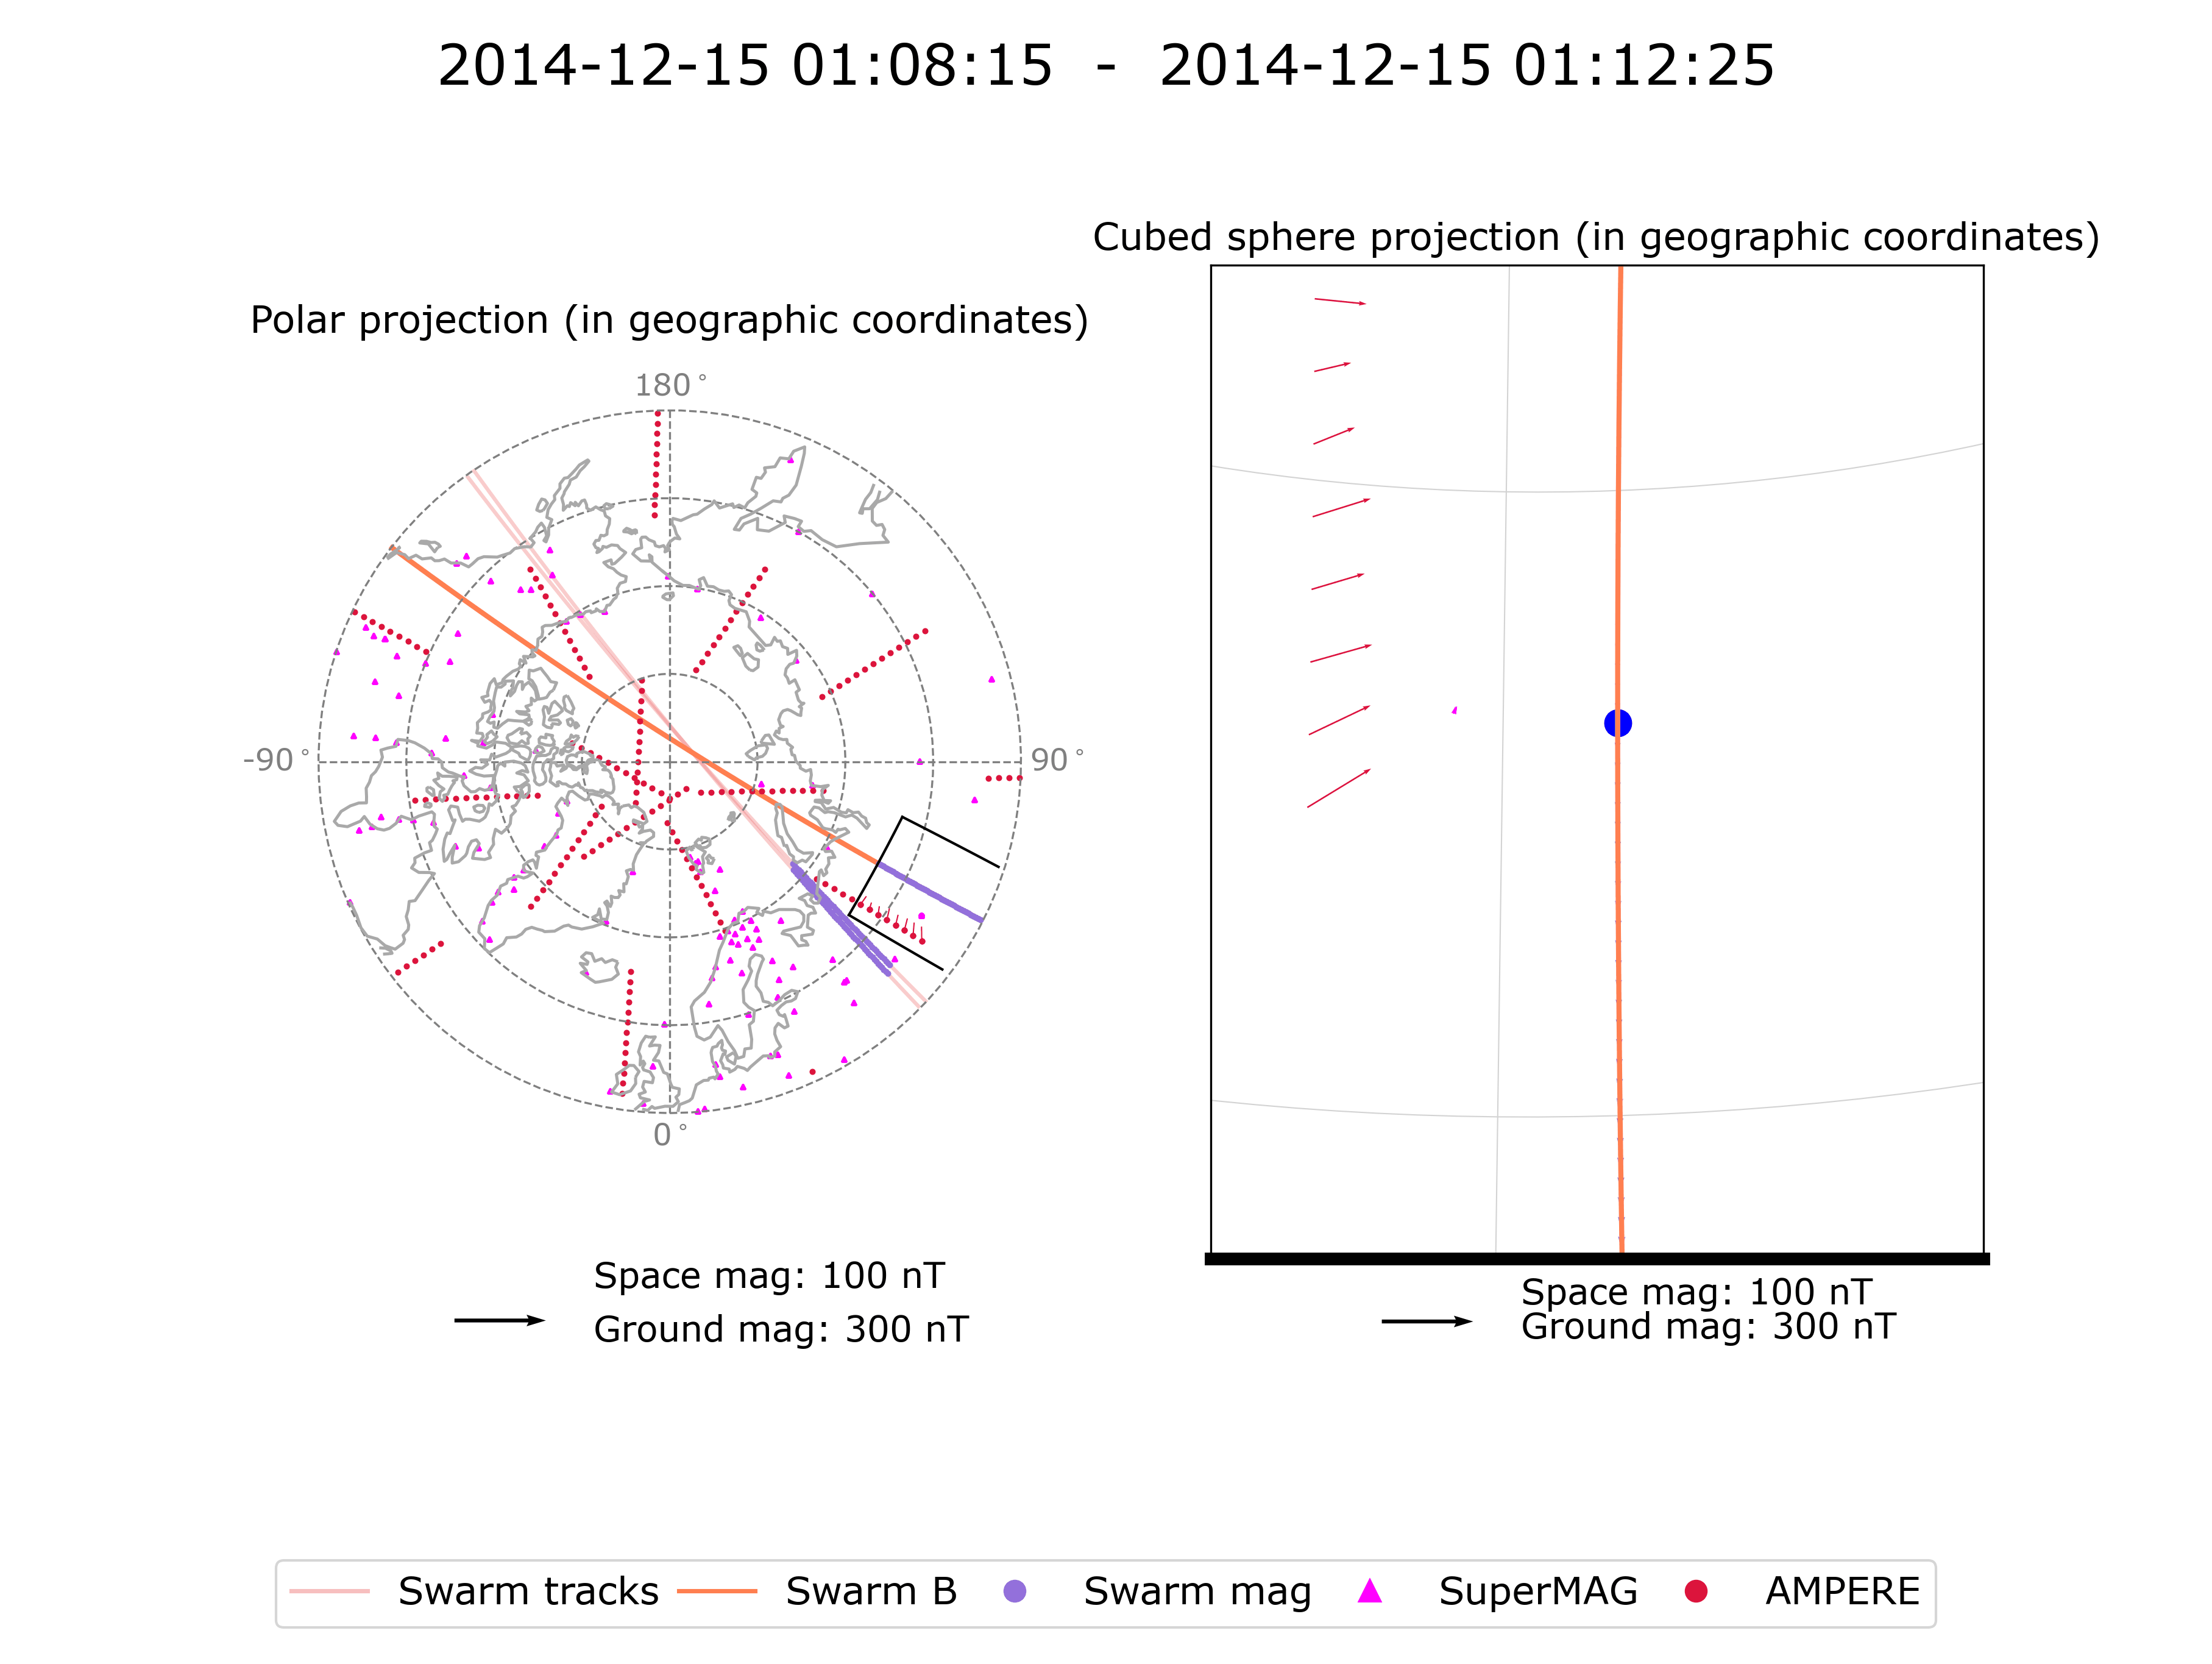

In [8]:
input_frames = lompe_input.plot_lompe_input(grids, analysis_times, data_objects_per_grid, show_global_data=True)

# Display GIF
lompe_input_gif_path = output_dir / f"lompe-input_swarm{sat_id}.gif"
display(IPImage(filename=lompe_input_gif_path))

## Lompe reconstruction

SwarmDF uses the [Lompe technique](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2022JA030356) to reconstruct the 2D ionospheric electrodynamics within each grid along the Swarm trajectory.  

Lompe formulates the reconstruction as a linear inverse problem, combining various observations (including magnetic field perturbations on ground and in space, plasma convection, electric fields, and field-aligned currents) into a common model based on Spherical Elementary Current Systems (SECS). Solving for these parameters yields consistent estimates of electric fields, currents, and magnetic perturbations across the analysis region. 

The method is flexible in both spatial extent and resolution, allowing it to adapt to the geometry and coverage of the available data. This makes it well suited for SwarmDF, where the analysis region is defined dynamically along a satellite trajectory and data coverage is heterogeneous.

**Ionospheric conductance estimates**

Conductances are a key input to the Lompe inversion and are treated as known quantities in order to keep the problem linear.

While this simplifies the inversion, ionospheric conductances are not directly known with high accuracy. They are strongly affected by auroral precipitation, which can vary rapidly in space and time. In contrast, the contribution from solar EUV radiation is more stable and better constrained. 

Lompe includes a built-in model for solar EUV-driven conductance, as well as implementations of the Hardy and Zhang & Paxton models for auroral precipitation.

Conductance estimates are computed using the following inputs:

- Kp index (used in the Hardy model)
- solar radio flux at 10.7 cm, used to scale EUV conductance
- a background conductance term


In [9]:
# Supported models: 'Zhang & Paxton model', 'Hardy model'
conductance_method = 'Zhang & Paxton model'

kp_value = 4 # Kp index (geomagnetic activity indicator)
f107_value = 100 # [s.f.u] Solar radio flux at 10.7 cm (solar activity indicator)
background_value = 2 # Background conductance (constant offset term)

# Dictionnary of input parameters
conductance_params = {"kp": kp_value, "f107": f107_value, "background": background_value}

# Compute Hall and Pedersen conductances
SHs, SPs = compute_conductances(conductance_method, conductance_params, analysis_times, grids)

**Regularization parameters** (⚠️ OK?)

Lompe uses two regularization parameters to control different aspects of the solution.

The first parameter (l1) penalizes rapid spatial variations in the model solution, and therefore controls the overall smoothness of the reconstructed fields. Increasing this parameter produces smoother solutions, while decreasing it allows more small-scale structure and closer fitting to the observations.

The second parameter (l2) controls the strength of the SECS-based regularization, which constrains the structure and amplitude of the ionospheric current system representation. Increasing this parameter enforces a more constrained current system, while decreasing it allows more flexibility in the reconstructed currents.

More generally, regularization represents prior assumptions about the expected structure of the ionospheric electrodynamics. The parameters determine how strongly these assumptions are enforced relative to the fit to the observations. Finding appropriate values typically requires some experimentation.

In [10]:
l1 = 1 # smoothness of solution
l2 = 1 # SECS regularization strength in magnetic eastward direction

**Lompe inversion along the Swarm trajectory**

SwarmDF applies the Lompe technique across the sequence of grids along the Swarm trajectory.

In [11]:
# run_lompe returns a dictionnary of Lompe models (one model per grid)
lompe_model_objects = run_lompe(analysis_times, grids, data_objects_per_grid, SHs, SPs, l1, l2)

Running Lompe analysis (l1=1.00, l2=1.00)...
space_mag_fac: Measurement uncertainty effectively changed from 3e-08 to 4.2426406871192844e-08
space_mag_fac: Measurement uncertainty effectively changed from 3e-08 to 4.2426406871192844e-08


**Finally, we visualize the reconstructed electrodynamic quantities along the Swarm trajectory.**

Lompe combined different types of measurements to provide a consistent picture of ionospheric electrodynamics within each grid along the selected trajectory. 

In the figure below, input data are shown as orange vectors, while the Lompe solution is represented by contours (red/blue) and black vectors. 

The reconstructed quantities include:
- convection flow field (vectors) and electric potential (contours) *(top left panel)*
- radial current density (contours) and horizontal magnetic field disturbances in space (vectors) *(top middle panel)*
- horizontal magnetic field perturbations on ground (vectors) and radial magnetic field perturbations (contours) *(top right panel)*
- Hall and Pedersen conductances *(bottom left and middle panels)*
- horizontal height-integrated ionospheric currents *(bottom right panel)*

The panel on the right shows the grid position and orientation in apex magnetic latitude and local time. All other panels are shown in geographic coordinates.

The upper color scale corresponds to conductances (mho), while the lower one corresponds to radial magnetic field perturbations (nT) and radial current density (µA/m²).

<!-- The uncertainty in the Lompe estimates depends on the distribution of the data, measurement error, and on how the data are related to electric field amplitudes via the ionospheric Ohm's law. -->

Lompe output figures for each time step saved in temporary folder: /Users/margot/Docs/Academia/Research/Python/SwarmDF/outputs/tmp
GIF saved in outputs directory: /Users/margot/Docs/Academia/Research/Python/SwarmDF/outputs/lompe-output_swarmB.gif


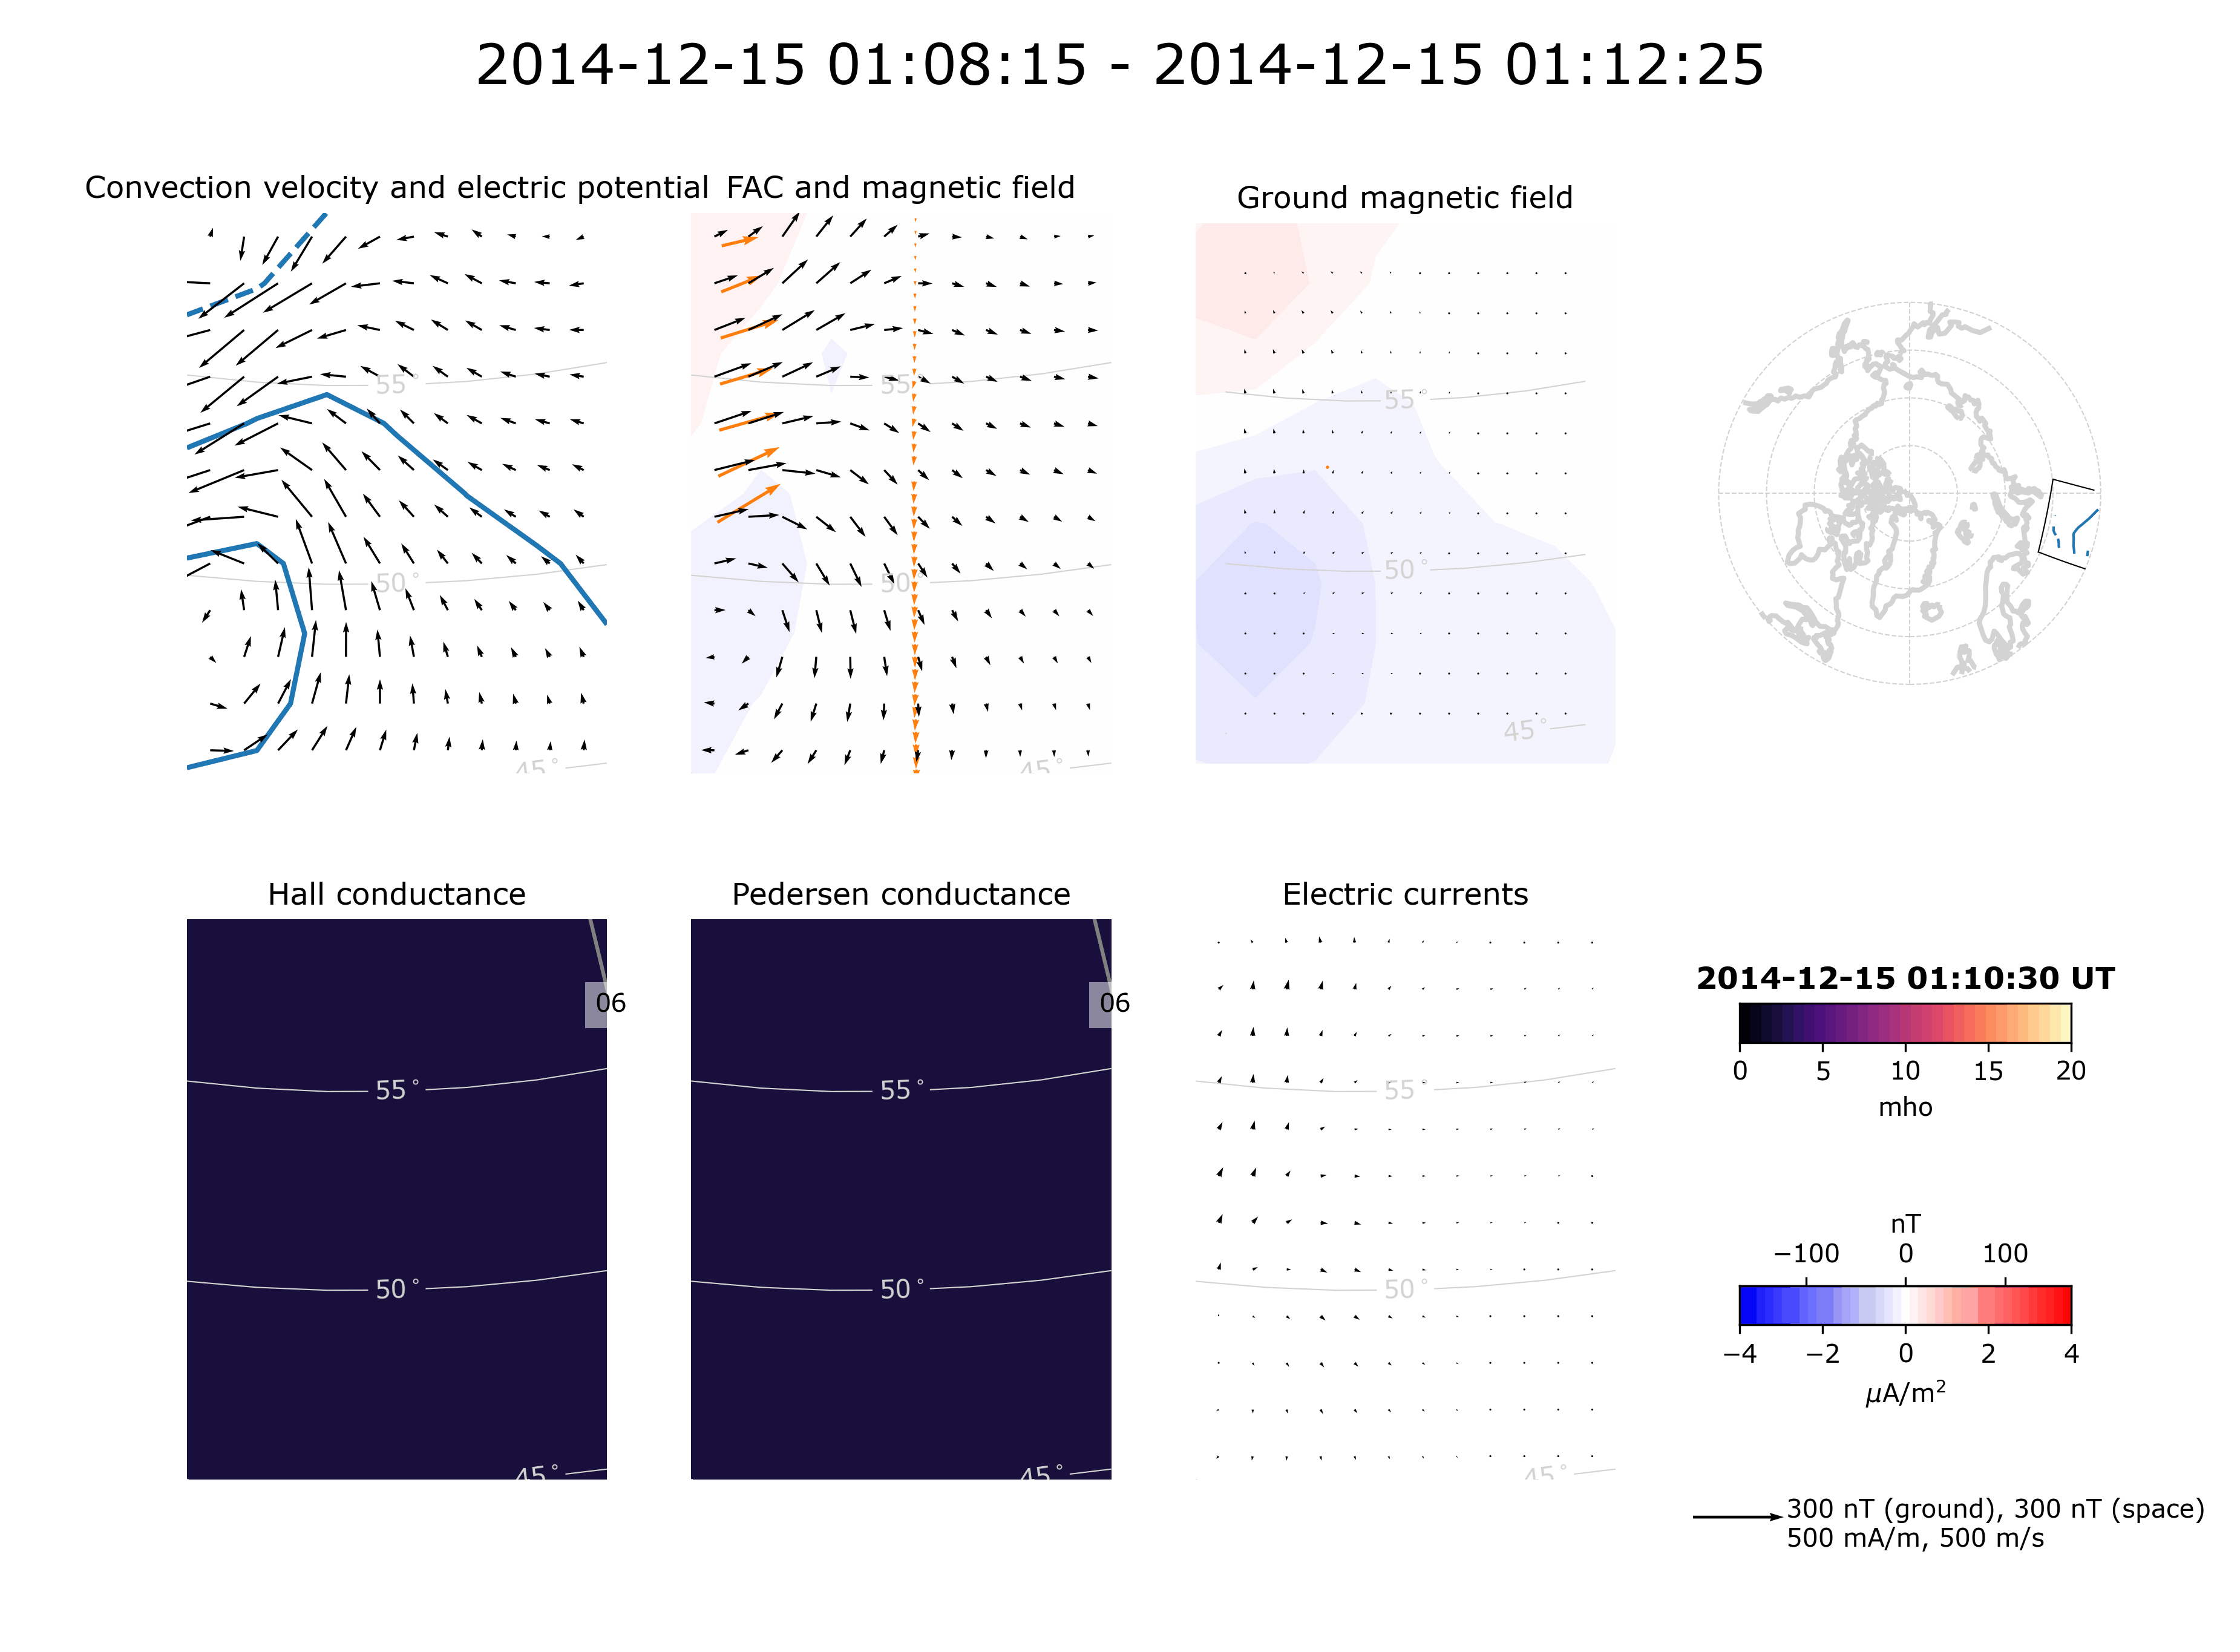

In [12]:
output_frames = plot_lompe_output(lompe_model_objects, sat_id) 

# Display GIF
lompe_output_gifpath = output_dir / f"lompe-output_swarm{sat_id}.gif"
display(IPImage(filename=lompe_output_gifpath))

## Validation

In real observations, the true ionospheric electrodynamics are unknown, which makes it difficult to directly evaluate the accuracy of a Lompe reconstruction. The result depends on factors such as data coverage and grid configuration, but there is no reference “truth” for comparison.

SwarmDF overcomes this limitation by including a validation tool, [LompeOSSE](https://github.com/Margot-D/lompe_osse), based on Observation System Simulation Experiments (OSSEs). LompeOSSE uses synthetic electrodynamics from Gamera simulations to evaluate the experiment configuration and the performance of the Lompe inversion. 

⚠️ Note: LompeOSSE is still under development and is not yet publicly available. This part of the notebook is therefore not functional at the moment.

**Input to LompeOSSE**

The main input to LompeOSSE is the set of Lompe models generated during the previous inversion step. 

Two optional parameters allow exploration of different physical configurations in the Gamera simulation:
- snapshot: selects a specific Gamera simulation run, each representing a different physical scenario 
- time_offset: rotates the Gamera snapshot in magnetic local time (MLT)

For further details, see the LompeOSSE documentation.

In [13]:
# Available Gamera snapshots: 
#0 #2 #3 #12 #13 #14 #16 #19 #20 #21 #22 
# (inspect with find-Gamera-snapshot.py in LompeOSSE)

snapshot = 0
time_offset = 0 # [MLT hours] 

**LompeOSSE analysis along the Swarm trajectory**

SwarmDF applies LompeOSSE in each grid along the Swarm trajectory. 

In each analysis region, observational inputs to the Lompe model are replaced with synthetic data derived from Gamera simulations, while the grid configuration and data coverage are kept unchanged. The Lompe inversion is then applied to the synthetic datasets, and the reconstructed electrodynamics can be directly compared to the known reference state from the simulation.

This makes it possible to evaluate how factors such as data availability and grid resolution affect the reconstruction.

`run_lompeOSSE` returns the synthetic Lompe models, and the set of synthetic electrodynamic quantities across grids along the selected Swarm trajectory.

In [14]:
lompeOSSE_model_objects, gamera_quantities = run_lompeOSSE(lompe_model_objects, time_offset, snapshot)


 Running LompeOSSE validation...
Loading Gamera data/snapshot #0
Gamera_output 0.03392854193225503
LompeOSSE 2.591591328382492e-05

 Initializing synthetic model (2014-12-15 01:10:30)...

 Scanning user datasets and searching for corresponding Gamera data...
efield dataset not found
convection dataset not found
ground_mag dataset found..
Getting Gamera magnetic field data
..Gamera ground_mag data extracted
get_B: 3.1633500829339027
space_mag_full dataset not found
space_mag_fac dataset found..
Getting Gamera magnetic field data
..Gamera space_mag_fac data extracted
get_B: 3.2027644170448184
space_mag_fac dataset found..
Getting Gamera magnetic field data
..Gamera space_mag_fac data extracted
get_B: 3.129317041952163
fac dataset not found
extract qunatities: 9.495766042266041
extract conductances: 1.2917444109916687e-06

 Clearing input model...
Adding Gamera datasets
...Synthetic model generated
total make_osse_model 9.495798209216446
make_osse_model 9.4958162503317
space_mag_fac: Mea

**We can finally assess the reconstruction accuracy.**

The synthetic electrodynamics from Gamera simulations provide a known reference state, allowing direct comparison between: 
- the original (“truth”) fields, and
- the fields reconstructed by LompeOSSE. 

Agreement between the two indicates good reconstruction performance.

<!-- ⚠️ Keep in mind that the gamera snapshot has an influence too?  -->

In [ ]:
lompeOSSE_frames, gamera_frames = plot_lompeOSSE_output(lompeOSSE_model_objects, gamera_quantities)

# Display original Gamera GIF
Gamera_gifpath = output_dir / f"GAMERA_electrodynamics.gif"
display(IPImage(filename=Gamera_gifpath))

# Display OSSE-reconstruction GIF
lompeOSSE_gifpath = output_dir / f"lompeOSSE_electrodynamics.gif"
display(IPImage(filename=lompeOSSE_gifpath))


 Generating LompeOSSE output...
## 2014-12-15 01:10:30 ##
Getting Gameraaa Hall conductance
griddata: 7.0932638752274215
get Hall conductance FUNCTION: 9.283534042071551
Getting Gameraaa Pedersen conductance
griddata: 7.253717250190675
get Pedersen conductance FUNCTION: 9.467487167101353
Getting Gameraaa Hall conductance
griddata: 7.696792542003095
get Hall conductance FUNCTION: 9.990480416920036
Getting Gameraaa Pedersen conductance


If visual inspection is not sufficient, we can quantify the agreement between the original synthetic fields and the Lompe reconstruction using correlation analysis.

As an example, we compare the synthetic electric potential with its reconstructed counterpart. 

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import io
import imageio.v2 as imageio
from PIL import Image as PILImage 

# # Re-run LompeOSSE with different parameters:
# snapshot=0
# time_offset=0
# lompeOSSE_model_objects, gamera_quantities = run_lompeOSSE(lompe_model_objects, time_offset, snapshot)

gameras = [entry["gamera_output"] for entry in gamera_quantities]
lompes = [entry["osse_model"] for entry in lompeOSSE_model_objects]
cts = [entry["ct"] for entry in lompeOSSE_model_objects]

figs=[]
for gamera, lompe, t in zip(gameras, lompes, cts):

    grid = lompe.grid_J

    # Extract electric potential from Gamera simulation
    truth_potential = gamera.get_potential(grid.lon, grid.lat, t) # in [V]

    # Extract electric potential from LompeOSSE reconstruction 
    recon_potential = lompe.E_pot(grid.lon, grid.lat, t) * 1e-3 # in [V]

    # Flatten data
    truth = np.asarray(truth_potential).ravel()
    recon = np.asarray(recon_potential).ravel()

    # Compute correlation
    corr = np.corrcoef(truth, recon)[0, 1]

    # Plot
    fig, ax = plt.subplots()

    ax.scatter(truth, recon, s=5, alpha=0.5)    
    ax.plot([truth.min(), truth.max()], [truth.min(), truth.max()], 'k--', linewidth=1)

    ax.set_xlabel("Synthetic (truth) potential")
    ax.set_ylabel("OSSE-reconstructed potential")
    ax.set_title(f"LompeOSSE validation: correlation = {corr:.3f} \n {t}")

    # Save figure to memory buffer
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    plt.close(fig)
    buf.seek(0)

    figs.append(imageio.imread(buf))

# Save GIF
images = [PILImage.fromarray(f) for f in figs]
images[0].save("correlation_plot.gif", save_all=True, append_images=images[1:], duration=750, loop=0)

# Display
display(IPImage(filename="correlation_plot.gif"))

The scatter plot compares synthetic truth and reconstructed electric potential.
The dashed line indicates perfect agreement.

TODO add loop=0 in    with imageio.get_writer(output, mode="I", duration=gif_speed) as writer in (lompe input)

TODO change the name of variable "gamera_models" in lompeosse_analysis and in lompeosse_analysis_UI and in code_generator (they are not models!)